# Processamento da Iluminação Publica (IP_data)

In [44]:
import os
from pathlib import Path

# Configurar diretório base do projeto
notebook_dir = Path.cwd()
if notebook_dir.name == "src": os.chdir(notebook_dir.parent)

print(f"Diretório de trabalho: {Path.cwd()}")

Diretório de trabalho: /Users/tiagoalves/gits/isep/ANADI_DI_G9_2026


In [45]:
import os
print(os.getcwd())
print(os.listdir())

/Users/tiagoalves/gits/isep/ANADI_DI_G9_2026
['requirements.txt', 'docs', 'README.md', '.gitignore', '.git', 'figuras', 'data', 'src']


In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

In [47]:
# Importar dados do Excel
data = pd.read_excel('data/IP_data.xlsx')

print('Dados importados:')
print(data)

Dados importados:
       Ano  Mês Distrito        Concelho                Freguesia  \
0     2026    2   Leiria      Alvaiázere                 Almoster   
1     2026    2   Leiria      Alvaiázere                 Almoster   
2     2026    2   Leiria      Alvaiázere                 Almoster   
3     2026    2   Leiria      Alvaiázere                    Pelmá   
4     2026    2   Leiria      Alvaiázere               Alvaiázere   
...    ...  ...      ...             ...                      ...   
9295  2026    2   Aveiro  Sever do Vouga  Silva Escura e Dornelas   
9296  2026    2   Aveiro           Vagos                   Calvão   
9297  2026    2   Aveiro           Vagos                   Calvão   
9298  2026    2   Aveiro           Vagos      Gafanha da Boa Hora   
9299  2026    2   Aveiro           Vagos                     Ouca   

          Tipo de Lâmpada  Luminárias  Lâmpadas por Luminária  Lâmpadas  \
0                     LED       716.0                   715.0     715.0   
1  

## Criar Variáveis

In [48]:
# 1 se tipo de lâmpada é Sódio ou Mercúrio, 0 for outro tipo
data['Is_Ineficiente'] = data['Tipo de Lâmpada'].isin(['Sódio', 'Mercúrio']).astype(int)

print(f"Distribuição Is_Inefiente:")
print(data['Is_Ineficiente'].value_counts())

Distribuição Is_Inefiente:
Is_Ineficiente
0    5835
1    3465
Name: count, dtype: int64


In [49]:
# Criar variável Potência kW
# Concertendo potência de W para kW

data['Potencia_kw'] = data['Potência Instalada Total (W)'] / 1000

print(f"\nEstatísticas Potencia_kW: ")
print(data['Potencia_kw'].describe())


Estatísticas Potencia_kW: 
count    8483.000000
mean       21.278778
std        58.003748
min         0.015000
25%         0.350000
50%         4.080000
75%        18.291200
max      1044.700000
Name: Potencia_kw, dtype: float64


## Agregação por Concelho

In [50]:
# Agrupar por CodDistritoConcelho

agrupado = data.groupby('CodDistritoConcelho').agg(
    P_IP_TOTAL = ('Potencia_kw', 'sum'),
    P_IP_Inef = ('Potencia_kw', lambda x: x[data.loc[x.index, 'Is_Ineficiente'] == 1].sum())
).reset_index()

print("\n Agregação por Conselho:")
print(agrupado)


 Agregação por Conselho:
     CodDistritoConcelho   P_IP_TOTAL  P_IP_Inef
0                    101   910.887701    244.320
1                    102   451.711801     28.020
2                    103   657.071801     73.545
3                    104   585.974400    115.720
4                    105  1055.192001    144.420
..                   ...          ...        ...
273                 1820   169.397800     28.640
274                 1821   769.826899    116.075
275                 1822   145.009600     20.555
276                 1823  2249.259902    692.979
277                 1824   178.892000      0.000

[278 rows x 3 columns]


In [51]:
# Mostrar informações adicionais

print(f"\nTotal de concelhos: {len(agrupado)}")

print(f"P_IP_TOTAL (soma global): {agrupado['P_IP_TOTAL'].sum():.2f} kW")

print(f"P_IP_Inef (soma global): {agrupado['P_IP_Inef'].sum():.2f} kW")

print(f"% Potência Ineficiente: {(agrupado['P_IP_Inef'].sum() / agrupado['P_IP_TOTAL'].sum() * 100):.2f}%")



Total de concelhos: 278
P_IP_TOTAL (soma global): 180507.87 kW
P_IP_Inef (soma global): 61708.66 kW
% Potência Ineficiente: 34.19%


# Processamento dos Postos de Transformação (PTD data)

In [52]:
# Importar dados do Excel
ptd_data = pd.read_excel('data/PTD_data.xlsx')

print('Dados importados:')
print(data)

Dados importados:
       Ano  Mês Distrito        Concelho                Freguesia  \
0     2026    2   Leiria      Alvaiázere                 Almoster   
1     2026    2   Leiria      Alvaiázere                 Almoster   
2     2026    2   Leiria      Alvaiázere                 Almoster   
3     2026    2   Leiria      Alvaiázere                    Pelmá   
4     2026    2   Leiria      Alvaiázere               Alvaiázere   
...    ...  ...      ...             ...                      ...   
9295  2026    2   Aveiro  Sever do Vouga  Silva Escura e Dornelas   
9296  2026    2   Aveiro           Vagos                   Calvão   
9297  2026    2   Aveiro           Vagos                   Calvão   
9298  2026    2   Aveiro           Vagos      Gafanha da Boa Hora   
9299  2026    2   Aveiro           Vagos                     Ouca   

          Tipo de Lâmpada  Luminárias  Lâmpadas por Luminária  Lâmpadas  \
0                     LED       716.0                   715.0     715.0   
1  

In [53]:
# Converter nível de utilização para decimal

# Converter 'Nível de Utilização [%]' de formato '60%-79%' para valor decimal (ex: 0.79)
# Extrai o último número antes do '%' final

ptd_data['Utilização Decimal'] = (
    ptd_data['Nível de Utilização [%]']
    .astype(str)
    .str.extract(r'(\d+)%$')[0] # Extrai o número antes do último '%'
    .astype(float) / 100
)

print("\nConversão Nível de Utilização:")
print(ptd_data[['Nível de Utilização [%]', 'Utilização Decimal']].drop_duplicates().sort_values('Utilização Decimal'))



Conversão Nível de Utilização:
    Nível de Utilização [%]  Utilização Decimal
4                    0%-19%                0.19
8                   20%-39%                0.39
9                   40%-59%                0.59
0                   60%-79%                0.79
7                   80%-99%                0.99
3                     +100%                1.00
245                     N/D                 NaN


# Agrupar por CodDistritoConcelho

In [54]:
agrupado_ptd = ptd_data.groupby('CodDistritoConcelho').agg(
    Cap_PTD = ('Potência instalada [kVA]', 'sum'),
    Util_Media = ('Utilização Decimal', 'mean'),
    N_PTDs = ('Código de Instalação', 'count')
).reset_index()

print("\nAgregação PTD por Conselho")
print(agrupado_ptd)


Agregação PTD por Conselho
     CodDistritoConcelho  Cap_PTD  Util_Media  N_PTDs
0                    101   105715    0.477593     388
1                    102    54540    0.469948     194
2                    103    55628    0.543009     223
3                    104    41884    0.527387     236
4                    105   197485    0.475475     509
..                   ...      ...         ...     ...
273                 1820    11820    0.619219      66
274                 1821    46645    0.530407     274
275                 1822    11995    0.520933      79
276                 1823   228706    0.537171     789
277                 1824    20160    0.520420     150

[278 rows x 4 columns]


In [55]:
# Mostrar informações adicionais

print(f"\nTotal de concelhos com PTD: {len(agrupado_ptd)}")
print(f"Cap_PTD total: {agrupado_ptd['Cap_PTD'].sum():.2f} kVA")
print(f"Utilização média global: {agrupado_ptd['Util_Media'].mean():.2%}")
print(f"Total de PTDs: {agrupado_ptd['N_PTDs'].sum()}")

print("\nEstatísticas dos PTDs por concelho:")
print(agrupado_ptd.describe())


Total de concelhos com PTD: 278
Cap_PTD total: 21809691.00 kVA
Utilização média global: 51.03%
Total de PTDs: 72027

Estatísticas dos PTDs por concelho:
       CodDistritoConcelho       Cap_PTD  Util_Media       N_PTDs
count           278.000000  2.780000e+02  278.000000   278.000000
mean            985.208633  7.845213e+04    0.510333   259.089928
std             530.261552  1.458702e+05    0.067260   241.989354
min             101.000000  3.470000e+03    0.331176    19.000000
25%             533.500000  1.739775e+04    0.462379   111.250000
50%            1008.500000  3.176400e+04    0.516125   176.500000
75%            1412.750000  8.448775e+04    0.562876   344.250000
max            1824.000000  1.767583e+06    0.645568  2278.000000


In [56]:
# =========================================
# Criar dataset final consolidado
# =========================================

# Juntar agregação da IP com agregação dos PTDs
df_final = pd.merge(
    agrupado,
    agrupado_ptd,
    on="CodDistritoConcelho",
    how="inner"
)

# Recuperar informação descritiva dos municípios
info_municipios = data[["CodDistritoConcelho", "Distrito", "Concelho"]].drop_duplicates()

# Juntar distrito e concelho ao dataset final
df_final = pd.merge(
    df_final,
    info_municipios,
    on="CodDistritoConcelho",
    how="left"
)

# =========================================
# Criar variáveis derivadas do enunciado
# =========================================

# Ganho LED: potência libertada pela substituição de lâmpadas ineficientes
df_final["Ganho_LED"] = df_final["P_IP_Inef"] * 0.65

# Folga da rede: capacidade disponível com margem de segurança de 92%
df_final["PFolga"] = (df_final["Cap_PTD"] * 0.92) * (1 - df_final["Util_Media"])

# Carga VE: carga necessária para carregadores de 22 kW em todos os PTDs
df_final["PVE"] = df_final["N_PTDs"] * 22 * 0.60

# Saldo final de viabilidade
df_final["D"] = df_final["PFolga"] + df_final["Ganho_LED"] - df_final["PVE"]

# Rate de ineficiência
df_final["Rate_Ineficiencia"] = df_final["P_IP_Inef"] / df_final["P_IP_TOTAL"]

# Tratar possíveis divisões por zero ou valores infinitos
df_final["Rate_Ineficiencia"] = df_final["Rate_Ineficiencia"].replace([float("inf"), -float("inf")], pd.NA)
df_final["Rate_Ineficiencia"] = df_final["Rate_Ineficiencia"].fillna(0)

# =========================================
# Reorganizar colunas
# =========================================

df_final = df_final[
    [
        "Distrito",
        "Concelho",
        "CodDistritoConcelho",
        "P_IP_TOTAL",
        "P_IP_Inef",
        "Rate_Ineficiencia",
        "Cap_PTD",
        "Util_Media",
        "N_PTDs",
        "Ganho_LED",
        "PFolga",
        "PVE",
        "D"
    ]
]

# =========================================
# Visualização do dataset final
# =========================================

print("Preview do dataset final consolidado:\n")
display(df_final.head())

# =========================================
# Estatísticas globais do dataset
# =========================================

summary_stats = pd.DataFrame({
    "Indicador": [
        "Número total de concelhos",
        "Potência total de iluminação pública (kW)",
        "Potência ineficiente total (kW)",
        "Capacidade total dos PTDs (kVA)",
        "Número total de PTDs"
    ],
    "Valor": [
        len(df_final),
        df_final["P_IP_TOTAL"].sum(),
        df_final["P_IP_Inef"].sum(),
        df_final["Cap_PTD"].sum(),
        df_final["N_PTDs"].sum()
    ]
})

display(summary_stats)

# =========================================
# Guardar dataset final
# =========================================

df_final.to_csv("data/dataset_final.csv", index=False)

print("\nDataset final guardado em: data/dataset_final.csv")

Preview do dataset final consolidado:



,Distrito,Concelho,CodDistritoConcelho,P_IP_TOTAL,P_IP_Inef,Rate_Ineficiencia,Cap_PTD,Util_Media,N_PTDs,Ganho_LED,PFolga,PVE,D
0,Aveiro,Águeda,101,910.887701,244.320,0.268222,105715,0.477593,388,158.80800,50808.195148,5121.6,45845.403148
1,Aveiro,Albergaria-a-Velha,102,451.711801,28.020,0.062031,54540,0.469948,194,18.21300,26596.303834,2560.8,24053.716834
2,Aveiro,Anadia,103,657.071801,73.545,0.111928,55628,0.543009,223,47.80425,23387.762452,2943.6,20491.966702
3,Aveiro,Arouca,104,585.974400,115.720,0.197483,41884,0.527387,236,75.21800,18211.314133,3115.2,15171.332133
4,Aveiro,Aveiro,105,1055.192001,144.420,0.136866,197485,0.475475,509,93.87300,95298.999935,6718.8,88674.072935


,Indicador,Valor
0,Número total de concelhos,2.780000e+02
1,Potência total de iluminação pública (kW),1.805079e+05
2,Potência ineficiente total (kW),6.170866e+04
3,Capacidade total dos PTDs (kVA),2.180969e+07
4,Número total de PTDs,7.202700e+04



Dataset final guardado em: data/dataset_final.csv


# 4.3. Análise e Exploração de Dados

## Mix tecnológico da iluminação pública

Nesta secção analisa-se a distribuição da potência instalada de iluminação pública entre tecnologia eficiente (LED) e tecnologia convencional.

- Potência convencional: potência associada a luminárias classificadas como ineficientes (`P_IP_Inef`), correspondendo a tecnologias Sódio ou Mercúrio.
- Potência LED: diferença entre a potência total instalada (`P_IP_TOTAL`) e a potência ineficiente.

Objetivos da análise:
- visualizar o peso relativo da tecnologia LED face à convencional;
- identificar se a potência ineficiente se concentra num grupo restrito de municípios.

Esta etapa corresponde a uma análise de estatística descritiva, recorrendo a representações gráficas para comparar categorias tecnológicas e identificar padrões de distribuição da potência instalada.

In [57]:
# =========================================
# Cálculo da potência LED
# =========================================

df_final["P_IP_LED"] = df_final["P_IP_TOTAL"] - df_final["P_IP_Inef"]

display(df_final[["Concelho","P_IP_TOTAL","P_IP_Inef","P_IP_LED"]].head())

# =========================================
# Totais globais
# =========================================

total_led = df_final["P_IP_LED"].sum()
total_conv = df_final["P_IP_Inef"].sum()
total_ip = df_final["P_IP_TOTAL"].sum()

perc_led = total_led / total_ip
perc_conv = total_conv / total_ip

print("Distribuição global da potência de iluminação pública:\n")

print(f"Potência total LED: {total_led:,.2f} kW ({perc_led:.2%})")
print(f"Potência total Convencional: {total_conv:,.2f} kW ({perc_conv:.2%})")
print(f"Potência total instalada: {total_ip:,.2f} kW")

,Concelho,P_IP_TOTAL,P_IP_Inef,P_IP_LED
0,Águeda,910.887701,244.320,666.567701
1,Albergaria-a-Velha,451.711801,28.020,423.691801
2,Anadia,657.071801,73.545,583.526801
3,Arouca,585.974400,115.720,470.254400
4,Aveiro,1055.192001,144.420,910.772001


Distribuição global da potência de iluminação pública:

Potência total LED: 118,799.21 kW (65.81%)
Potência total Convencional: 61,708.66 kW (34.19%)
Potência total instalada: 180,507.87 kW


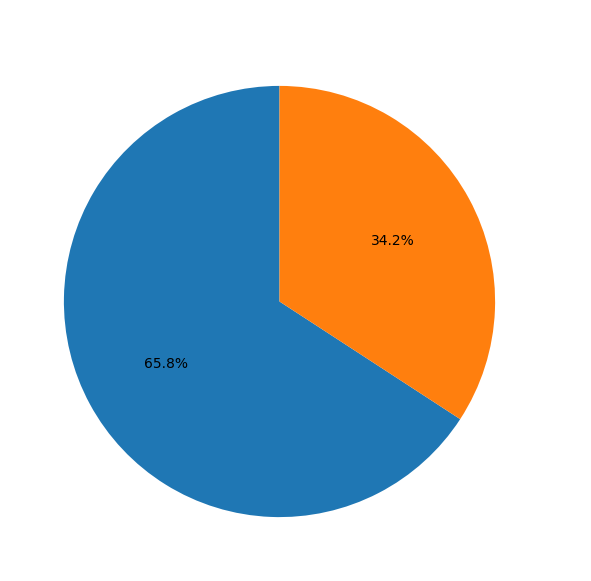

In [58]:
labels = ['LED', 'Convencional']
values = [total_led, total_conv]

plt.figure(figsize=(7, 7))

wedges, texts, autotexts = plt.pie(
    values,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

# 🔹 labels (fora) → branco
for text in texts:
    text.set_color('white')

# 🔹 percentagens (dentro) → preto
for autotext in autotexts:
    autotext.set_color('black')

plt.title("Mix Tecnológico da Iluminação Pública", color='white')

plt.show()

### Concentração da potência ineficiente por município

Para avaliar se a potência ineficiente se encontra concentrada num grupo restrito de municípios, analisam-se os concelhos com maior valor de `P_IP_Inef`.

Esta análise permite identificar os municípios onde a substituição de tecnologia ineficiente poderá gerar maiores ganhos potenciais de eficiência energética e maior libertação de potência.

Concentração da potência ineficiente:
• Top 10 municípios: 35.78% da potência ineficiente total
• Top 20 municípios: 54.14% da potência ineficiente total


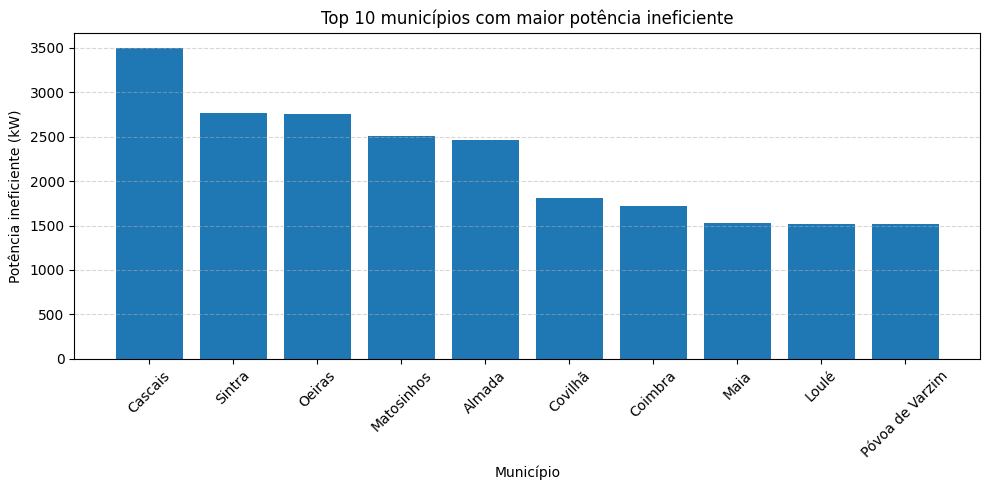

In [59]:
# Ordenar municípios por potência ineficiente
top_municipios = df_final.sort_values("P_IP_Inef", ascending=False).head(10)

# Calcular percentagens de concentração
top10_share = top_municipios["P_IP_Inef"].sum() / df_final["P_IP_Inef"].sum()
top20_share = (
        df_final.sort_values("P_IP_Inef", ascending=False)
        .head(20)["P_IP_Inef"]
        .sum() / df_final["P_IP_Inef"].sum()
)

print("Concentração da potência ineficiente:")
print(f"• Top 10 municípios: {top10_share:.2%} da potência ineficiente total")
print(f"• Top 20 municípios: {top20_share:.2%} da potência ineficiente total")

# Gráfico de barras
plt.figure(figsize=(10,5))

plt.bar(
    top_municipios["Concelho"],
    top_municipios["P_IP_Inef"]
)

plt.title("Top 10 municípios com maior potência ineficiente")
plt.xlabel("Município")
plt.ylabel("Potência ineficiente (kW)")

plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretação

O gráfico evidencia que a potência associada a luminárias ineficientes se encontra concentrada num número relativamente reduzido de municípios.

O município de **Cascais** apresenta o valor mais elevado de potência ineficiente, seguido por **Sintra, Oeiras, Matosinhos e Almada**, indicando uma maior presença de tecnologia convencional nestas zonas.

Verifica-se ainda que os **10 municípios com maior potência ineficiente concentram cerca de 35.78% da potência ineficiente total**, enquanto os **20 principais representam aproximadamente 54.14%**.

Estes resultados sugerem que a substituição da iluminação convencional por tecnologia **LED** nestes municípios poderá gerar ganhos significativos de eficiência energética e libertação de capacidade na rede elétrica.

## Comparação da utilização dos PTDs por distrito

Nesta secção comparam-se as distribuições do **nível médio de utilização dos Postos de Transformação de Distribuição (PTD)** entre os distritos de Lisboa, Porto, Aveiro e Setúbal.

Para essa comparação utiliza-se um **boxplot**, uma representação gráfica que permite analisar simultaneamente:

- mediana
- quartis
- amplitude interquartil
- presença de valores extremos (outliers)

Esta visualização permite avaliar diferenças na variabilidade da carga da rede entre os distritos analisados e identificar qual apresenta maior dispersão nos níveis de utilização dos PTDs.

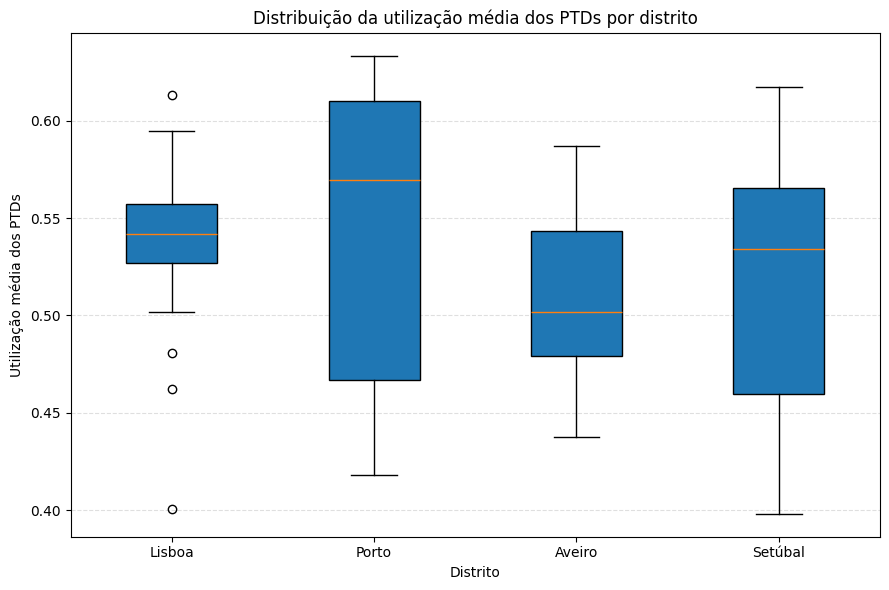


Variância da utilização média dos PTDs por distrito:


,Variância
Distrito,
Lisboa,0.0026
Porto,0.0065
Aveiro,0.0018
Setúbal,0.0051


In [60]:
# Distritos a analisar
ordem = ["Lisboa", "Porto", "Aveiro", "Setúbal"]

# Filtrar apenas os distritos pedidos
df_boxplot = df_final[df_final["Distrito"].isin(ordem)].copy()

# Criar listas de dados por distrito
dados = [
    df_boxplot[df_boxplot["Distrito"] == distrito]["Util_Media"]
    for distrito in ordem
]

# Gráfico boxplot simples
plt.figure(figsize=(9,6))

plt.boxplot(
    dados,
    tick_labels=ordem,
    patch_artist=True
)

plt.title("Distribuição da utilização média dos PTDs por distrito")
plt.xlabel("Distrito")
plt.ylabel("Utilização média dos PTDs")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# Calcular variância
variancia = (
    df_boxplot.groupby("Distrito")["Util_Media"]
    .var()
    .reindex(ordem)
    .round(4)
)

# Mostrar tabela com variâncias
print("\nVariância da utilização média dos PTDs por distrito:")
display(variancia.to_frame(name="Variância"))

### Interpretação dos Resultados

A distribuição da utilização média dos PTDs nos distritos de Lisboa, Porto, Aveiro e Setúbal foi analisada através de **boxplots**, permitindo observar a mediana, os quartis, a dispersão dos valores e a presença de possíveis **outliers** na variável `Util_Media`.

Visualmente, verifica-se que o distrito do **Porto apresenta maior dispersão**, evidenciada por uma caixa mais extensa e whiskers mais longos, indicando maior variabilidade nos níveis médios de utilização da rede.

Para complementar a análise gráfica, foi calculada a **variância da utilização média por distrito**, obtendo-se aproximadamente:

- Porto: **0.0065**
- Setúbal: **0.0051**
- Lisboa: **0.0026**
- Aveiro: **0.0018**

Estes resultados confirmam que o **distrito do Porto apresenta a maior variabilidade na utilização média dos PTDs**, enquanto **Aveiro apresenta uma distribuição mais homogénea** entre os concelhos analisados.

## Prevalência de valores omissos e identificação de outliers

Nesta etapa pretende-se analisar a qualidade dos dados disponíveis relativamente à utilização dos PTDs.

Algumas variáveis apresentam valores não determinados ou censurados, nomeadamente representados por **"N/D"** (não disponível) ou **"<20"** (valor inferior ao limite de divulgação). Estes valores não correspondem a observações numéricas válidas e devem ser tratados antes de qualquer análise estatística.

Assim, procede-se à identificação e quantificação destes valores no dataset. Posteriormente, os valores válidos são utilizados para analisar a distribuição da ocupação da rede e identificar a presença de **outliers**, recorrendo a representações gráficas adequadas.

In [61]:
colunas_analise = [
    "Potência Geração [kW]",
    "Número de Clientes",
    "Número de Clientes Produtores"
]

resultados = []

for col in colunas_analise:

    total = len(ptd_data[col])
    nd = (ptd_data[col].astype(str) == "N/D").sum()
    lt20 = (ptd_data[col].astype(str) == "<20").sum()

    resultados.append({
        "Variável": col,
        "Total Registos": total,
        "N/D": nd,
        "% N/D": nd/total,
        "<20": lt20,
        "% <20": lt20/total
    })

df_resultados = pd.DataFrame(resultados)

display(
    df_resultados.style.format({
        "% N/D": "{:.2%}",
        "% <20": "{:.2%}"
    })
)

,Variável,Total Registos,N/D,% N/D,<20,% <20
0,Potência Geração [kW],72027,70191,97.45%,0,0.00%
1,Número de Clientes,72027,0,0.00%,21180,29.41%
2,Número de Clientes Produtores,72027,0,0.00%,70191,97.45%


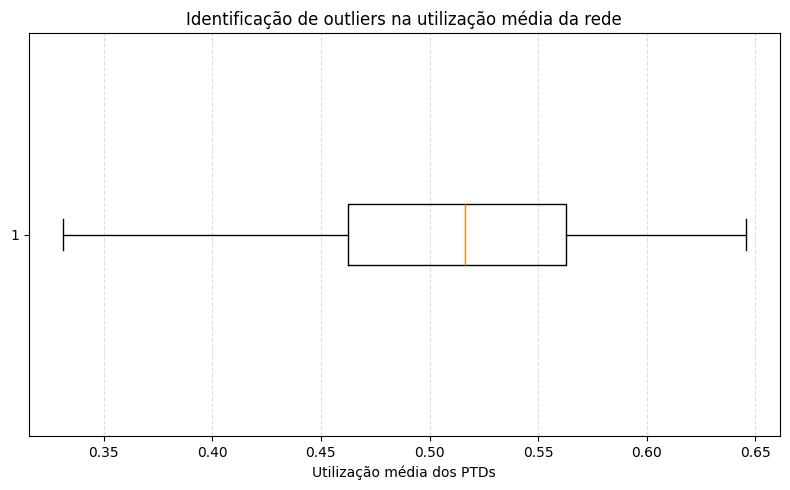

In [62]:
plt.figure(figsize=(8,5))

plt.boxplot(df_final["Util_Media"], vert=False)

plt.title("Identificação de outliers na utilização média da rede")
plt.xlabel("Utilização média dos PTDs")

plt.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Interpretação dos resultados

A análise do dataset original dos PTDs revelou a presença de valores indeterminados representados por `"N/D"` e `"<20"` em algumas variáveis.

Observa-se que a variável **Potência de Geração [kW]** apresenta uma proporção muito elevada de valores `"N/D"`, indicando que, na maioria dos PTDs, não existe produção associada ou essa informação não se encontra disponível no dataset. Por outro lado, a variável **Número de Clientes Produtores** apresenta predominantemente valores `"<20"`, o que significa que o número de produtores ligados ao PTD é inferior a 20 ou que o valor exato foi censurado por motivos de confidencialidade estatística.

Relativamente à ocupação da rede, o boxplot da variável **Util_Media** permite analisar a distribuição da utilização média dos PTDs entre os concelhos. Verifica-se que a maioria dos valores se concentra aproximadamente entre **46% e 56%**, com uma mediana próxima de **51%**.

Não se observam outliers extremamente pronunciados na distribuição agregada por concelho, sugerindo que os níveis médios de utilização da rede elétrica apresentam uma **variabilidade moderada e relativamente homogénea** entre os concelhos analisados.

## Estatísticas descritivas do nível de utilização médio

Nesta secção apresentam-se estatísticas descritivas da variável **Util_Media**, correspondente ao **nível médio de utilização dos PTDs**, para os concelhos de **Coimbra, Évora, Braga e Faro**.

As medidas calculadas incluem:

- média
- quartis
- desvio padrão
- assimetria
- curtose

Estas estatísticas permitem caracterizar a **distribuição da utilização média da rede elétrica** nos concelhos selecionados, identificando diferenças na variabilidade, forma da distribuição e possíveis assimetrias nos níveis de ocupação da infraestrutura elétrica.

In [63]:
concelhos = ["Coimbra", "Évora", "Braga", "Faro"]

df_stats = ptd_data[ptd_data["Concelho"].isin(concelhos)]

tabela_434 = (
    df_stats.groupby("Concelho")["Utilização Decimal"]
    .agg(
        media="mean",
        Q1=lambda x: x.quantile(0.25),
        mediana="median",
        Q3=lambda x: x.quantile(0.75),
        desvio_padrao="std",
        assimetria="skew",
        curtose=lambda x: x.kurt()
    )
    .round(4)
)

display(tabela_434)

,media,Q1,mediana,Q3,desvio_padrao,assimetria,curtose
Concelho,,,,,,,
Braga,0.5423,0.39,0.59,0.79,0.2401,0.4280,-0.7116
Coimbra,0.5406,0.39,0.59,0.79,0.2322,0.2258,-0.7060
Faro,0.5549,0.39,0.59,0.59,0.2126,0.3009,-0.4757
Évora,0.4546,0.19,0.39,0.59,0.2425,0.6680,-0.4254


### Interpretação dos resultados

A tabela apresenta estatísticas descritivas do nível médio de utilização da rede elétrica nos concelhos de **Braga, Coimbra, Faro e Évora**.

Observa-se que os valores médios de utilização são semelhantes em **Braga (0.5423), Coimbra (0.5406) e Faro (0.5549)**, situando-se próximos de **54% de utilização média da capacidade dos PTDs**. Em contraste, **Évora apresenta uma média inferior (0.4546)**, indicando uma menor ocupação média da infraestrutura elétrica.

Os quartis mostram que a maior parte dos valores de utilização se concentra entre aproximadamente **0.39 e 0.79**, evidenciando uma variabilidade considerável entre os PTDs dentro de cada concelho.

O **desvio padrão**, situado entre cerca de **0.21 e 0.24**, confirma a existência de dispersão moderada nos níveis de utilização da rede.

Os valores positivos de **assimetria** indicam uma distribuição ligeiramente enviesada à direita, sugerindo a presença de alguns PTDs com níveis de utilização mais elevados.

Por fim, os valores negativos de **curtose** indicam distribuições relativamente mais achatadas do que a distribuição normal, refletindo uma dispersão mais uniforme dos níveis de utilização observados.

# 4.4 Inferência Estatística

* Considere a base de dados consolidada e selecione aleatoriamente uma amostra de 50 concelhos.
Use esta amostra para testar se o nível médio de ocupação da rede é inferior a um patamar de
referência (ex: 60\%), verificando previamente a normalidade dos dados.

* Selecione aleatoriamente duas amostras de 30 registos: uma de concelhos "Modernizados" (rácio de
LED acima da mediana) e outra de concelhos "Ineficientes". Use estas amostras para testar se o
estado médio de ocupação da rede difere significativamente entre os dois grupos.

* Considere três amostras aleatórias de 25 concelhos representativas de diferentes perfis de ocupação
da rede: Norte/Centro Litoral (Porto, Braga, Coimbra), Lisboa e Litoral Sul (Lisboa, Setúbal, Aveiro) e
Interior/Alentejo (Évora, Beja, Portalegre). Use estas amostras para testar a existência de diferenças
significativas nos níveis médios de carga da rede (ANOVA). Caso necessário, efetue uma análise post-
hoc adequada.

* Teste a existência de uma relação linear estatisticamente significativa entre a capacidade total de
transformação instalada e a carga de iluminação pública para a totalidade dos concelhos,
interpretando o coeficiente de correlação de Pearson.

## 4.4. Inferência Estatística
Nesta secção, vamos realizar testes de hipóteses estatísticas com um nível de significância de 5% para tirar conclusões sobre a capacidade da rede e o impacto da iluminação pública.

In [64]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

import os
from pathlib import Path

# Configurar diretório base do projeto
notebook_dir = Path.cwd()
if notebook_dir.name == "src": os.chdir(notebook_dir.parent)
df = pd.read_csv('data/dataset_final.csv')

### 4.4.1. Teste de Ocupação Média da Rede (Amostra Única)
**Objetivo:** Selecionar aleatoriamente uma amostra de 50 concelhos e testar se o nível médio de ocupação da rede (`Util_Media`) é inferior a 60%.

**Metodologia:** 1. Teste de Normalidade de Shapiro-Wilk para verificar as condições de aplicabilidade.
2. Teste T de uma amostra (One-Sample T-test) unilateral à esquerda.

In [65]:
# 1. Select a random sample of 50 municipalities
amostra_50 = df['Util_Media'].dropna().sample(n=50, random_state=42)

# 2. Shapiro-Wilk Test for Normality
# H0: Data follows a normal distribution
stat_shapiro, p_shapiro = stats.shapiro(amostra_50)
print(f"Shapiro-Wilk p-value: {p_shapiro:.4f}")

# 3. One-Sample T-test
# H0: Mean >= 0.60 | H1: Mean < 0.60
stat_t, p_t = stats.ttest_1samp(amostra_50, popmean=0.60, alternative='less')
print(f"T-test p-value: {p_t:.4f}")

Shapiro-Wilk p-value: 0.0523
T-test p-value: 0.0000


**Análise e Conclusão:**
* **Normalidade:** O teste de Shapiro-Wilk obteve um p-value de `0.0523`. Como este valor é ligeiramente maior que 0.05, não rejeitamos a hipótese nula, assumindo que os dados seguem uma distribuição normal. 

* **Conclusão do Teste:** O teste T obteve um p-value de `0.0000`. A 5% de significância, rejeitamos a hipótese nula. Conclui-se que a ocupação média é estatisticamente inferior a 60%. Isto indica que a rede tem, em média, folga disponível antes de qualquer substituição de lâmpadas.

### 4.4.2. Comparação de Concelhos Modernizados vs. Ineficientes
**Objetivo:** Testar se o estado médio de ocupação da rede difere significativamente entre concelhos "Modernizados" e "Ineficientes" utilizando duas amostras de 30 registos.

**Metodologia:**
Divisão dos dados com base na mediana do rácio de LED e aplicação de um Teste T para duas amostras independentes.


In [66]:
# Create LED ratio variable
df['Rate_LED'] = 1 - df['Rate_Ineficiencia']
mediana_led = df['Rate_LED'].median()

# Split the data
modernizados = df[df['Rate_LED'] > mediana_led]['Util_Media'].dropna()
ineficientes = df[df['Rate_LED'] <= mediana_led]['Util_Media'].dropna()

# Random samples of 30
amostra_mod = modernizados.sample(n=30, random_state=42)
amostra_inef = ineficientes.sample(n=30, random_state=42)

# Independent T-test (assuming equal variances for simplicity, but Levene's test can check this)
stat_ind, p_ind = stats.ttest_ind(amostra_mod, amostra_inef, equal_var=False)
print(f"Independent T-test p-value: {p_ind:.4f}")

Independent T-test p-value: 0.3071


**Análise e Conclusão:**
O Teste T para amostras independentes obteve um p-value de `0.3071`. Como este valor é maior que o nível de significância de 0.05, não rejeitamos a hipótese nula. Conclui-se que não existe uma diferença estatisticamente significativa no nível médio de ocupação da rede entre os concelhos com maior adoção de tecnologia LED e os concelhos mais ineficientes.

### 4.4.3. Análise de Variância (ANOVA) por Perfil Geográfico
**Objetivo:** Testar a existência de diferenças significativas nos níveis médios de carga da rede entre 3 perfis geográficos (Norte/Centro Litoral, Lisboa/Litoral Sul, Interior/Alentejo) usando amostras de 25 concelhos.

**Metodologia:** ANOVA a um fator (One-way ANOVA) seguida de análise post-hoc de Tukey caso se verifiquem diferenças.

In [67]:
# Define groups based on Distritos
norte_centro = ['Porto', 'Braga', 'Coimbra']
lisboa_sul = ['Lisboa', 'Setúbal', 'Aveiro']
interior = ['Évora', 'Beja', 'Portalegre']

# Filter and sample 25
g1 = df[df['Distrito'].isin(norte_centro)]['Util_Media'].dropna().sample(n=25, random_state=42, replace=True) # Used replace=True just in case there aren't 25 available
g2 = df[df['Distrito'].isin(lisboa_sul)]['Util_Media'].dropna().sample(n=25, random_state=42, replace=True)
g3 = df[df['Distrito'].isin(interior)]['Util_Media'].dropna().sample(n=25, random_state=42, replace=True)

# Run ANOVA
stat_anova, p_anova = stats.f_oneway(g1, g2, g3)
print(f"ANOVA p-value: {p_anova:.4f}")

# Post-Hoc Analysis (Only if ANOVA p-value < 0.05)
if p_anova < 0.05:
    # Prepare data for Tukey
    tukey_data = np.concatenate([g1, g2, g3])
    tukey_labels = ['Norte/Centro']*25 + ['Lisboa/Sul']*25 + ['Interior']*25
    tukey_results = pairwise_tukeyhsd(tukey_data, tukey_labels, alpha=0.05)
    print("\nResultados Post-Hoc de Tukey:")
    print(tukey_results)
else:
    print("\nComo o p-value da ANOVA é > 0.05, não há diferenças significativas, logo não é necessário teste post-hoc.")

ANOVA p-value: 0.0000

Resultados Post-Hoc de Tukey:
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1      group2    meandiff p-adj  lower  upper  reject
------------------------------------------------------------
  Interior   Lisboa/Sul   0.0965    0.0 0.0605 0.1324   True
  Interior Norte/Centro   0.1378    0.0 0.1018 0.1738   True
Lisboa/Sul Norte/Centro   0.0414 0.0202 0.0054 0.0774   True
------------------------------------------------------------


**Análise e Conclusão:**
A ANOVA resultou num p-value de `0.0000`. Assim, concluímos que existem diferenças significativas entre os níveis médios de carga das diferentes regiões. 
A análise post-hoc de Tukey revelou que as diferenças significativas residem entre todos os pares de regiões testados (todas as comparações indicam reject=True). Ou seja, o perfil do Interior difere significativamente tanto de Lisboa/Sul como do Norte/Centro, e Lisboa/Sul também difere significativamente do Norte/Centro.

### 4.4.4. Correlação Linear: Capacidade vs. Iluminação Pública
**Objetivo:** Testar se existe uma relação linear significativa entre a capacidade total de transformação instalada e a carga de iluminação pública para todos os concelhos.

In [68]:
# Drop missing values for these two specific columns
corr_df = df[['Cap_PTD', 'P_IP_TOTAL']].dropna()

# Calculate Pearson Correlation
r, p_corr = stats.pearsonr(corr_df['Cap_PTD'], corr_df['P_IP_TOTAL'])
print(f"Coeficiente de Correlação de Pearson (r): {r:.4f}")
print(f"P-value: {p_corr:.4f}")

Coeficiente de Correlação de Pearson (r): 0.9111
P-value: 0.0000


**Análise e Conclusão:**
A correlação de Pearson testada indicou um coeficiente r = `0.9111`, com um p-value de `0.0000`. Como o p-value é menor que o nível de significância de 5%, a relação é estatisticamente significativa. O valor de r sugere que existe uma forte e positiva correlação linear. Isto significa que concelhos com maior carga de iluminação pública tendem a ter uma capacidade total instalada significativamente maior nos seus transformadores.